In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import interpolate
from scipy.integrate import simpson

# Objetivo:

Replicar de forma efectiva la atenuación generada por la tierra que se muestra en el paper mcp from the heavens. Como marcadores de que está todo bien vamos a usar como prueba los gráficos:

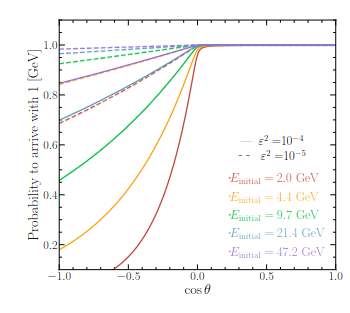


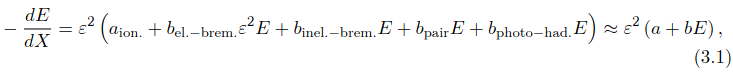

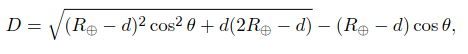

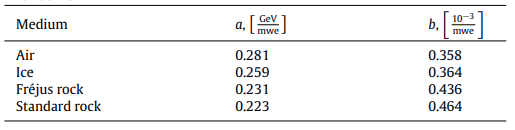

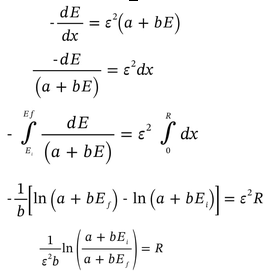

$$R = \frac{1}{\varepsilon^2 b}ln(\frac{1+\frac{b}{a}E_i}{1+\frac{b}{a}E_f})$$

In [2]:
def D_overburden(d,theta):
    '''
    Calculates the overburden distance D for a given depth d and zenith angle theta.
    d: depth in meters (of the experiment)
    theta: zenith angle in radians
    '''
    R_t = 6.378e6 # [m] Radio de la tierra
    D = np.sqrt((R_t-d)**2*np.cos(theta)**2+d*(2*R_t-d))-(R_t-d)*np.cos(theta)
    return D # resultado en METROS

In [3]:
# chequeo, en theta = 0, D = d, en theta = pi/2, D = sqrt(2*R_t*d)

D_overburden(2000, 0), D_overburden(2000, np.pi/2), np.sqrt(2*6.378e6*2000)

(np.float64(2000.0),
 np.float64(159712.24123403904),
 np.float64(159724.76326481125))

In [4]:
# Función R
def R_average(eps, Ei, Ef, a=None, b=None):
    '''
    Calculates the average distance R that a mCP travels in the earth 
        eps: mCP charge fraction (e.g., 1e-3 for a mCP with charge 0.001e)
        Ei: initial energy of the mCP in the surface(in GeV)
        Ef: final energy of the mCP in the surface(in GeV)
        returns: R in meters using the formula R = (1/eps^2)*(1/b)*log((1+(a/b)*Ei)/(1+(a/b)*Ef))*(1/2.65)

    b is in 1/mwe units, so we may need to convert it to 1/m since D is 
    in meters. The paper says that this value was calculated for a "standard
    rock shielding so we consider 1 mwe = (1/2.65) m of rock "
    '''

    if a is None:
        a = 0.223 # [GeV/mwe]
    if b is None:
        b = 4.64e-4 # [1/mwe]

    R = ((1/(eps**2))*(1/b))*np.log((1+(b/a)*Ei)/(1+(b/a)*Ef)) # [mwe]
    R = R*(1/2.65) # [m]
    return R 


Dado que R está en mwe y queremos que esté en metros tenemos que hacer la conversión de esa distancia. En teoría y con los dedos podría dividir por la densidad de la roca estándar, pero no sé si alcanza con eso.

$$
1 m.w.e = 100 g/cm²
$$

In [5]:
def P_arrival(eps, Ei, Ef, d, theta):
    '''
    Calculates the probability of arrival of a mCP at the detector given its charge fraction, initial and final energy, depth of the experiment, and zenith angle.
    eps: mCP charge fraction
    Ei: initial energy of the mCP in GeV
    Ef: final energy of the mCP in GeV
    d: depth of the experiment in meters
    theta: zenith angle in radians
    returns: probability of arrival at the detector
    '''
    D = D_overburden(d, theta) # Calculate overburden distance D
    R = R_average(eps, Ei, Ef) # Calculate average distance R that the mCP travels in the earth
    P = np.exp(-D/R) # Probability of arrival using the formula P = exp(-D/R)
    return P

In [6]:
# Probamos

Ef = 1 # GeV
Ei = np.array([2,4.4,9.7,21.4,47.2])# GeV
eps2 = np.array([1e-5,1e-4])
theta = np.linspace(-np.pi, 0, 1000) 
P_E0 = np.zeros((len(Ei), len(theta)))
P_E1 = np.zeros((len(Ei), len(theta)))
d = 1500 # Depth of the experiment in meters
for i in range(len(Ei)):
    P_0 = P_arrival(np.sqrt(eps2[0]), Ei[i], Ef, d, theta)
    P_1 = P_arrival(np.sqrt(eps2[1]), Ei[i], Ef, d, theta)
    P_E0[i,:] = P_0
    P_E1[i,:] = P_1

<>:5: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:6: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:5: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:6: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/tmp/ipykernel_13658/1037114879.py:5: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.plot(np.cos(theta), P_E0[i,:], label=f'$\epsilon ² = {eps2[0]}$, $E_i =${Ei[i]} GeV',color = colors[i],linestyle='--')
/tmp/ipykernel_13658/1037114879.py:6: SyntaxWarning: "\e" is an invalid escape

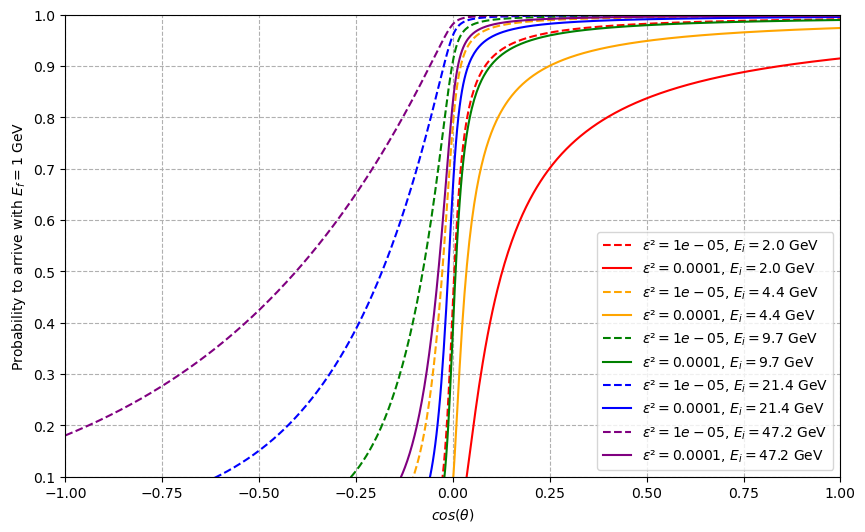

In [7]:
plt.close('all')
colors = ['red', 'orange', 'green', 'blue', 'purple']
plt.figure(figsize=(10, 6))
for i in range(len(Ei)):
    plt.plot(np.cos(theta), P_E0[i,:], label=f'$\epsilon ² = {eps2[0]}$, $E_i =${Ei[i]} GeV',color = colors[i],linestyle='--')
    plt.plot(np.cos(theta), P_E1[i,:], label=f'$\epsilon ² = {eps2[1]}$, $E_i =${Ei[i]} GeV', color = colors[i])
    plt.xlabel(f'$cos(\\theta)$')
    plt.ylabel('Probability to arrive with $E_f = 1$ GeV')
    plt.legend()
plt.xlim(-1, 1)
plt.ylim(0.1, 1)
plt.grid(linestyle='--')

## Probamos integrando en Ef